# Phase 1 — Dataset Generation Overview

This notebook validates the synthetic dataset generated for TalentMatch AI V1.1.

Objectives:

- Verify dataset sizes
- Check schema integrity
- Analyze class balance
- Inspect candidate distributions
- Inspect job distributions
- Analyze fit score behavior
- Validate engineered features
- Generate visualizations for documentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
candidates = pd.read_csv("../data/raw/candidates.csv")
jobs = pd.read_csv("../data/raw/jobs.csv")
applications = pd.read_csv("../data/raw/applications.csv")
model_df = pd.read_csv("../data/processed/model_training_dataset.csv")

print("Datasets loaded.")

Datasets loaded.


In [3]:
print("Candidates Shape :", candidates.shape)
print("Jobs Shape       :", jobs.shape)
print("Applications     :", applications.shape)
print("Model Dataset    :", model_df.shape)

Candidates Shape : (1000, 13)
Jobs Shape       : (100, 9)
Applications     : (10000, 8)
Model Dataset    : (10000, 18)


In [4]:
display(candidates.head())
display(jobs.head())
display(applications.head())
display(model_df.head())

,candidate_id,name,specialization,years_experience,education_level,skills,certifications,internships_count,projects_count,hackathons,research_papers,leadership_experience,gpa
0,C0001,Lena Verma,Machine Learning,1.5,Master's,Looker|Model Evaluation|Time Series Analysis|A...,2,2,3,1,0,1,3.52
1,C0002,Rahul Müller,NLP,1.7,Bachelor's,SQL|Matplotlib|NLP|Time Series Analysis|Java|A...,0,1,4,2,1,0,3.27
2,C0003,Zhang Garcia,Data Engineering,2.2,Bachelor's,C++|Feature Engineering|Google Sheets|Data Mod...,3,1,2,5,0,0,2.09
3,C0004,Neha Reddy,Data Engineering,2.5,Master's,Keras|Julia|R|Kubeflow|Excel|Docker,0,1,3,4,2,0,3.00
4,C0005,Divya Castillo,Data Science,1.8,Master's,Tableau|Docker|Linear Algebra|Statistics|SQL|N...,4,0,4,2,3,1,3.51


,job_id,title,job_family,preferred_specialization,seniority_level,min_experience,education_requirement,required_skills,required_certifications
0,J001,AI Research Engineer,Research,Machine Learning,Junior,1.7,Bachelor's,Airflow|XGBoost|Python|AWS|Teamwork|NoSQL|NumP...,0
1,J002,NLP Engineer,Research,NLP,Mid,2.8,Bachelor's,Stakeholder Management|Keras|AWS|PyTorch|Data ...,0
2,J003,AI Research Engineer,Research,Machine Learning,Junior,0.3,Master's,Keras|Plotly|Python|Terraform|Spark|Leadership...,0
3,J004,Research Scientist,Research,Machine Learning,Senior,9.6,Bachelor's,Kubeflow|AWS|Hugging Face|NumPy,2
4,J005,AI Research Engineer,Research,Machine Learning,Senior,11.2,Master's,Keras|PostgreSQL|AWS|Excel|C++|Kubeflow|Plotly...,1


,application_id,candidate_id,job_id,required_skill_count,matched_skill_count,missing_skill_count,fit_score,fit_label
0,A000001,C0508,J001,8,1,7,57.25,0
1,A000002,C0819,J001,8,3,5,58.55,1
2,A000003,C0453,J001,8,1,7,49.95,0
3,A000004,C0369,J001,8,1,7,56.33,0
4,A000005,C0243,J001,8,2,6,52.10,1


,application_id,candidate_id,job_id,skill_match_score,experience_gap,education_match,certification_gap,skill_coverage_ratio,projects_normalized,internships_normalized,gpa_normalized,hackathons_normalized,research_normalized,leadership_experience,specialization_match,seniority_match,fit_score,fit_label
0,A000001,C0508,J001,0.125,5.2,1,3,0.1912,0.375,0.50,0.8000,0.2,0.3333,0,0,0,57.25,0
1,A000002,C0819,J001,0.375,1.7,1,1,0.2647,0.625,0.75,0.5150,1.0,0.3333,1,0,0,58.55,1
2,A000003,C0453,J001,0.125,1.9,1,1,0.2206,0.625,0.00,0.5225,0.6,0.6667,1,1,0,49.95,0
3,A000004,C0369,J001,0.125,1.1,1,3,0.2353,0.250,0.50,0.7850,0.8,0.0000,0,0,0,56.33,0
4,A000005,C0243,J001,0.250,0.9,1,0,0.1618,0.500,0.00,0.7925,0.8,0.0000,1,0,0,52.10,1


In [5]:
print("===== CANDIDATES =====")
print(candidates.isnull().sum())

print("\n===== JOBS =====")
print(jobs.isnull().sum())

print("\n===== APPLICATIONS =====")
print(applications.isnull().sum())

print("\n===== MODEL DATASET =====")
print(model_df.isnull().sum())

===== CANDIDATES =====
candidate_id             0
name                     0
specialization           0
years_experience         0
education_level          0
skills                   0
certifications           0
internships_count        0
projects_count           0
hackathons               0
research_papers          0
leadership_experience    0
gpa                      0
dtype: int64

===== JOBS =====
job_id                      0
title                       0
job_family                  0
preferred_specialization    0
seniority_level             0
min_experience              0
education_requirement       0
required_skills             0
required_certifications     0
dtype: int64

===== APPLICATIONS =====
application_id          0
candidate_id            0
job_id                  0
required_skill_count    0
matched_skill_count     0
missing_skill_count     0
fit_score               0
fit_label               0
dtype: int64

===== MODEL DATASET =====
application_id            0
candidate_

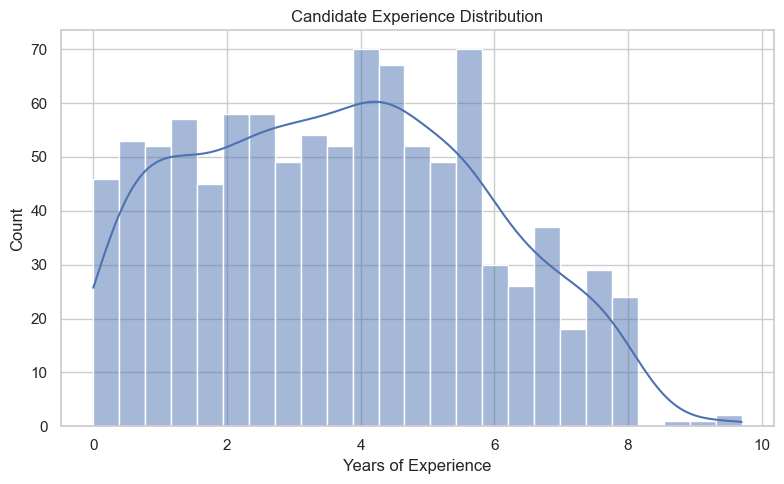

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(
    candidates["years_experience"],
    bins=25,
    kde=True
)
plt.title("Candidate Experience Distribution")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig(
    "../screenshots/experience_distribution.png",
    dpi=150
)

plt.show()

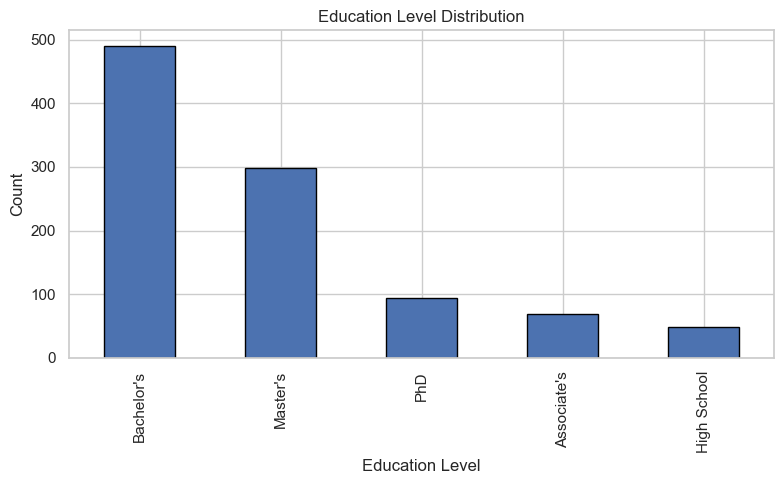

In [7]:
plt.figure(figsize=(8,5))
candidates["education_level"]\
    .value_counts()\
    .plot(
        kind="bar",
        edgecolor="black"
    )
plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig(
    "../screenshots/education_distribution.png",
    dpi=150
)

plt.show()

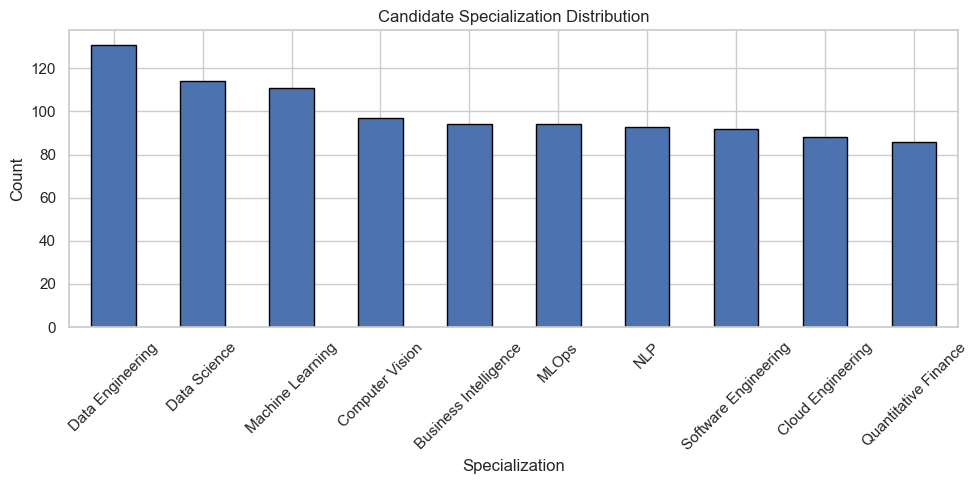

In [8]:
plt.figure(figsize=(10,5))
candidates["specialization"]\
    .value_counts()\
    .plot(
        kind="bar",
        edgecolor="black"
    )
plt.title("Candidate Specialization Distribution")
plt.xlabel("Specialization")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../screenshots/specialization_distribution.png",
    dpi=150
)

plt.show()

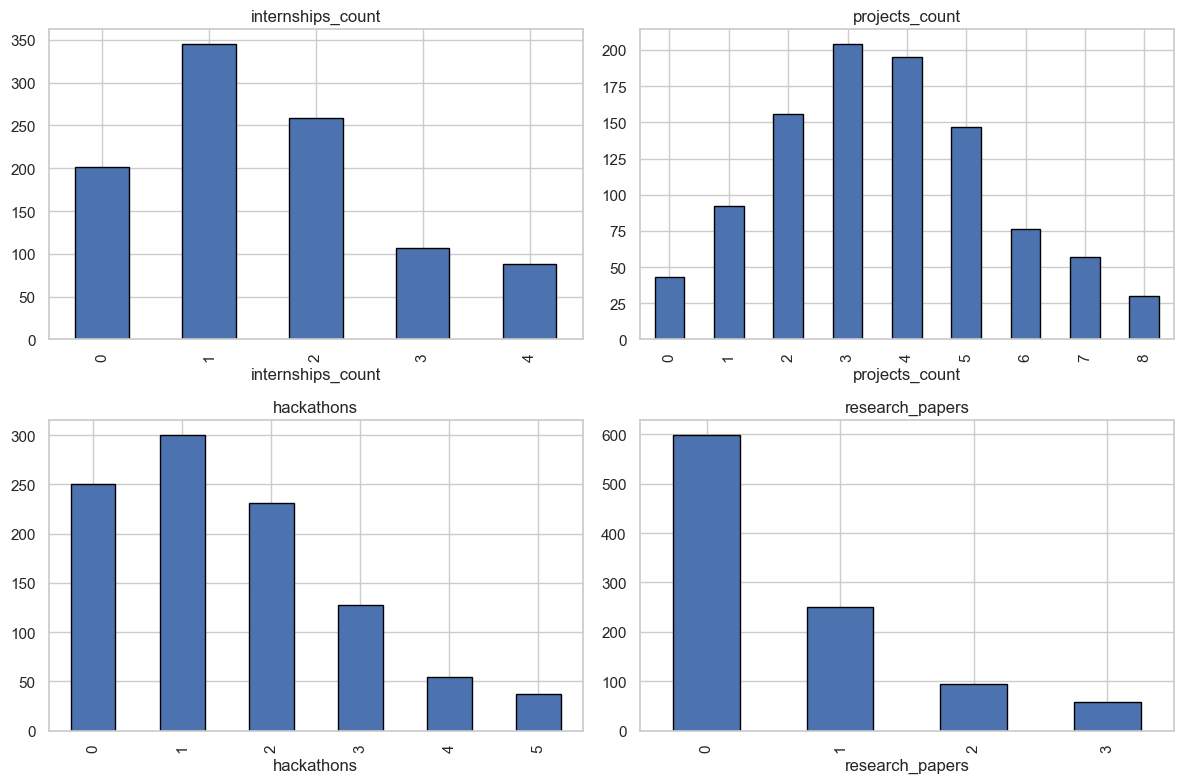

In [9]:
student_features = [
    "internships_count",
    "projects_count",
    "hackathons",
    "research_papers"
]

fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, feature in zip(axes.flatten(), student_features):
    candidates[feature]\
        .value_counts()\
        .sort_index()\
        .plot(
            kind="bar",
            ax=ax,
            edgecolor="black"
        )

    ax.set_title(feature)

plt.tight_layout()

plt.savefig(
    "../screenshots/student_features.png",
    dpi=150
)

plt.show()

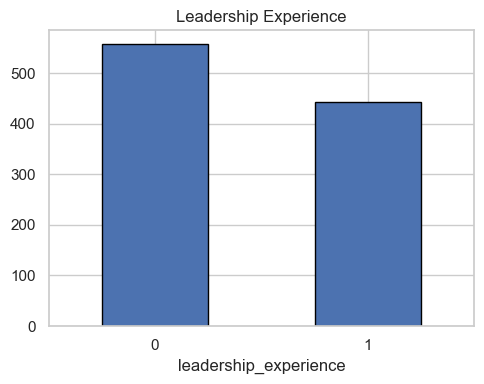

In [10]:
plt.figure(figsize=(5,4))
candidates["leadership_experience"]\
    .value_counts()\
    .plot(
        kind="bar",
        edgecolor="black"
    )
plt.title("Leadership Experience")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../screenshots/leadership_distribution.png",
    dpi=150
)

plt.show()

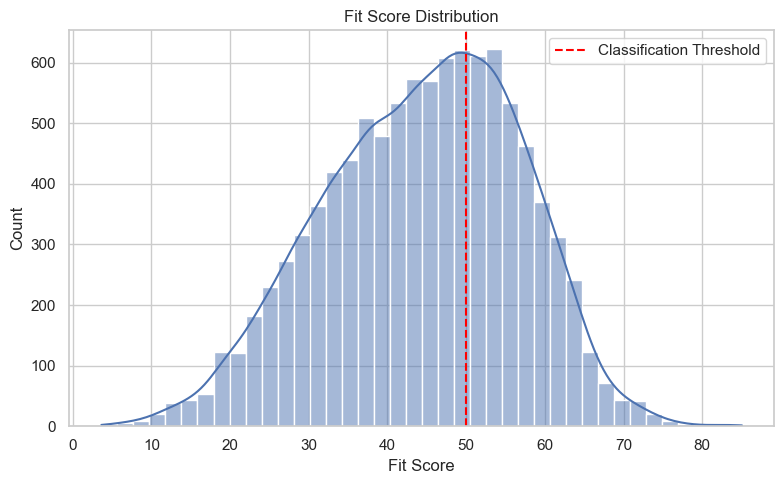

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(
    applications["fit_score"],
    bins=40,
    kde=True
)
plt.axvline(
    50,
    color="red",
    linestyle="--",
    label="Classification Threshold"
)
plt.legend()
plt.title("Fit Score Distribution")
plt.xlabel("Fit Score")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig(
    "../screenshots/fit_score_distribution.png",
    dpi=150
)

plt.show()

fit_label
0    62.1
1    37.9
Name: proportion, dtype: float64


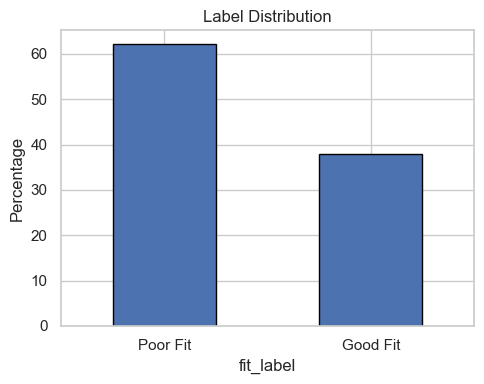

In [12]:
balance = (
    applications["fit_label"]
    .value_counts(normalize=True)
    * 100
)

print(balance)

plt.figure(figsize=(5,4))

balance.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Label Distribution")

plt.xticks(
    [0,1],
    ["Poor Fit","Good Fit"],
    rotation=0
)

plt.ylabel("Percentage")
plt.tight_layout()

plt.savefig(
    "../screenshots/label_distribution.png",
    dpi=150
)

plt.show()

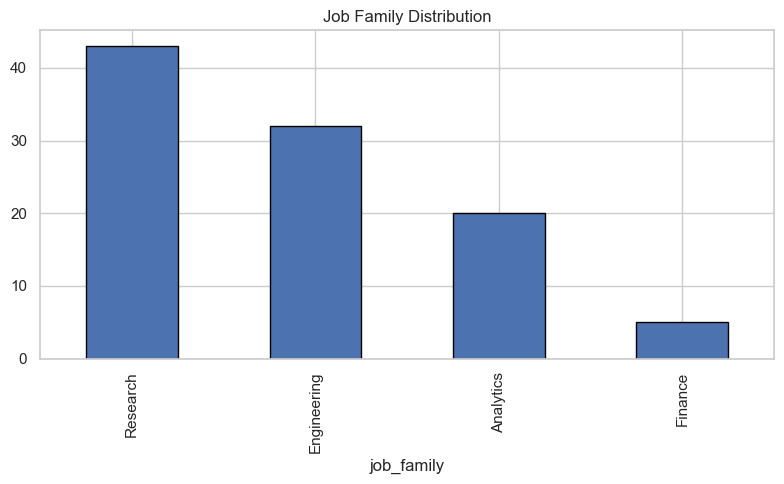

In [13]:
plt.figure(figsize=(8,5))

jobs["job_family"]\
    .value_counts()\
    .plot(
        kind="bar",
        edgecolor="black"
    )

plt.title("Job Family Distribution")

plt.tight_layout()

plt.savefig(
    "../screenshots/job_family_distribution.png",
    dpi=150
)

plt.show()

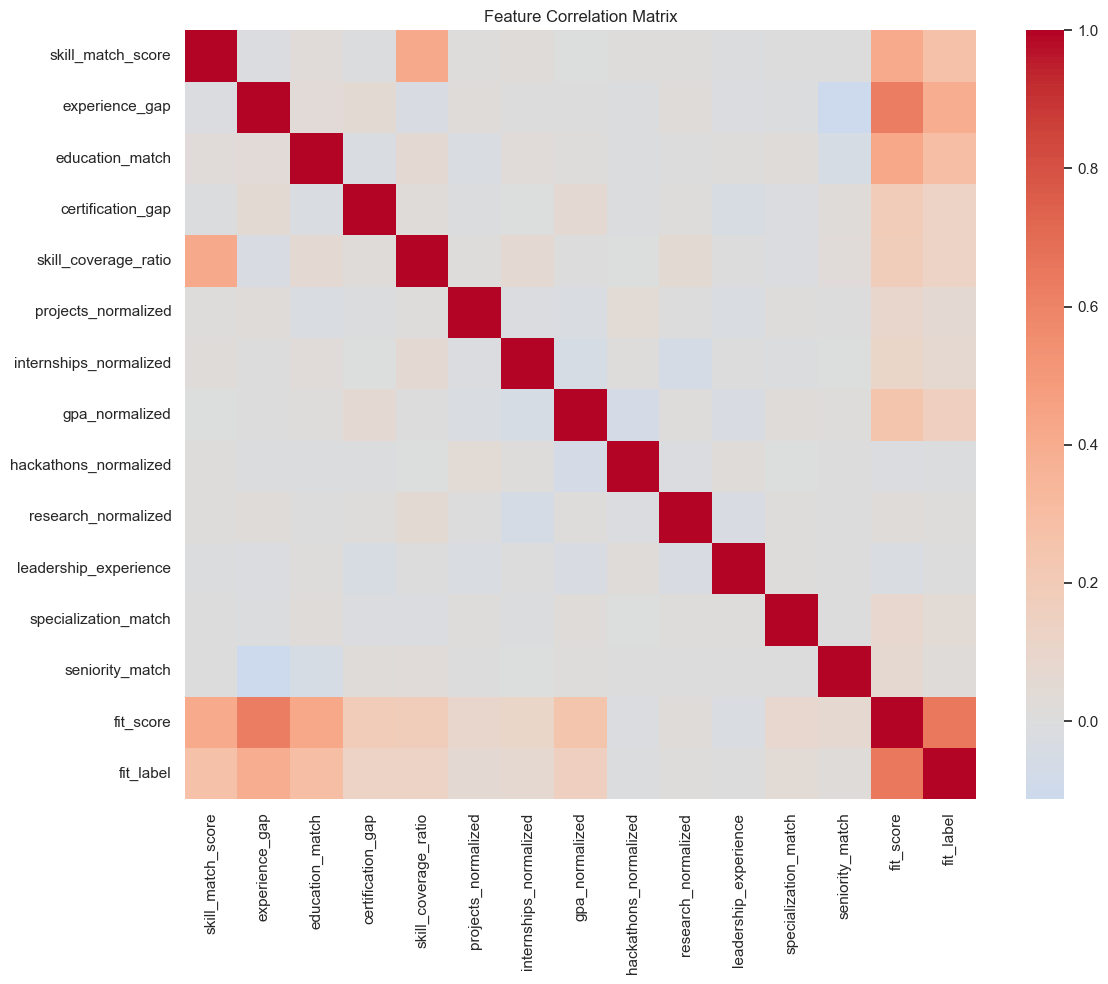

In [14]:
numeric_df = model_df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../screenshots/correlation_matrix.png",
    dpi=150
)

plt.show()

In [15]:
model_df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
skill_match_score,10000.0,0.173,0.143,0.000,0.083,0.167,0.250,1.000
experience_gap,10000.0,0.026,3.312,-5.000,-2.700,0.200,2.600,9.300
education_match,10000.0,0.668,0.471,0.000,0.000,1.000,1.000,1.000
certification_gap,10000.0,0.895,1.092,0.000,0.000,1.000,2.000,4.000
skill_coverage_ratio,10000.0,0.171,0.059,0.074,0.118,0.176,0.221,0.265
projects_normalized,10000.0,0.452,0.240,0.000,0.250,0.500,0.625,1.000
internships_normalized,10000.0,0.383,0.295,0.000,0.250,0.250,0.500,1.000
gpa_normalized,10000.0,0.748,0.146,0.500,0.622,0.752,0.872,1.000
hackathons_normalized,10000.0,0.312,0.268,0.000,0.200,0.200,0.400,1.000
research_normalized,10000.0,0.206,0.294,0.000,0.000,0.000,0.333,1.000


In [16]:
total = len(applications)

positive = applications["fit_label"].sum()

negative = total - positive

print("Applications :", total)

print("Good Fit     :", positive)

print("Poor Fit     :", negative)

print(
    "Positive Rate:",
    round(positive / total * 100, 2),
    "%"
)

Applications : 10000
Good Fit     : 3790
Poor Fit     : 6210
Positive Rate: 37.9 %


In [17]:
features = [
    c for c in model_df.columns
    if c not in
    [
        "application_id",
        "candidate_id",
        "job_id",
        "fit_score",
        "fit_label"
    ]
]

print("Model Features")

for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")

Model Features
1. skill_match_score
2. experience_gap
3. education_match
4. certification_gap
5. skill_coverage_ratio
6. projects_normalized
7. internships_normalized
8. gpa_normalized
9. hackathons_normalized
10. research_normalized
11. leadership_experience
12. specialization_match
13. seniority_match


# Conclusion

The synthetic dataset generation pipeline has been validated.

Key observations:

- Dataset generated successfully
- Candidate and job distributions appear realistic
- Fit score follows expected distribution
- Class balance is acceptable
- Engineered features are ready for EDA and ANN training

Next Phase:

Phase 2 — Exploratory Data Analysis (EDA)